In [64]:
#Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

In [79]:
#Load Dataset
df = pd.read_csv("customer_data.csv")

In [80]:
df.head()

,id,gender,age,salary,buy
0,15624510,Male,19.0,19000.0,0
1,15810944,Male,35.0,20000.0,0
2,15668575,Female,26.0,43000.0,0
3,15603246,Female,27.0,57000.0,0
4,15804002,Male,19.0,76000.0,0


In [81]:
df.shape

(400, 5)

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      400 non-null    int64  
 1   gender  398 non-null    object 
 2   age     398 non-null    float64
 3   salary  398 non-null    float64
 4   buy     400 non-null    int64  
dtypes: float64(2), int64(2), object(1)
memory usage: 15.8+ KB


In [69]:
df.describe()

,id,age,salary,buy
count,4.000000e+02,398.000000,398.000000,400.000000
mean,1.569154e+07,37.660804,69899.497487,0.357500
std,7.165832e+04,10.482468,34102.231100,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,30.000000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [70]:
df.isnull().sum()

id        0
gender    2
age       2
salary    2
buy       0
dtype: int64

In [71]:
# Fill numerical columns with mean
df['age'] = df['age'].fillna(df['age'].mean())
df['salary'] = df['salary'].fillna(df['salary'].mean())

# Fill categorical column with mode
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])

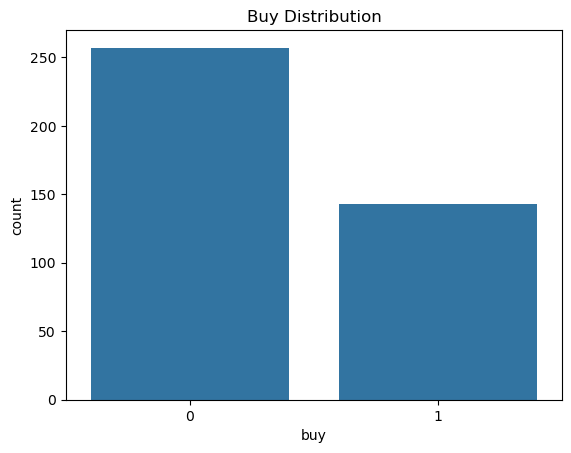

In [72]:
# Target distribution
sns.countplot(x='buy', data=df)
plt.title("Buy Distribution")
plt.show()

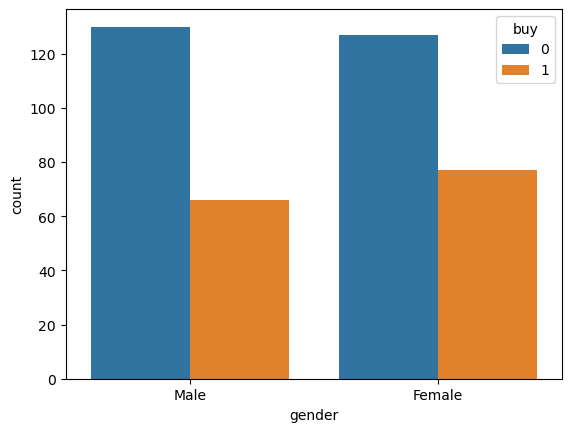

In [73]:
# Gender vs Buy
sns.countplot(x='gender', hue='buy', data=df)
plt.show()

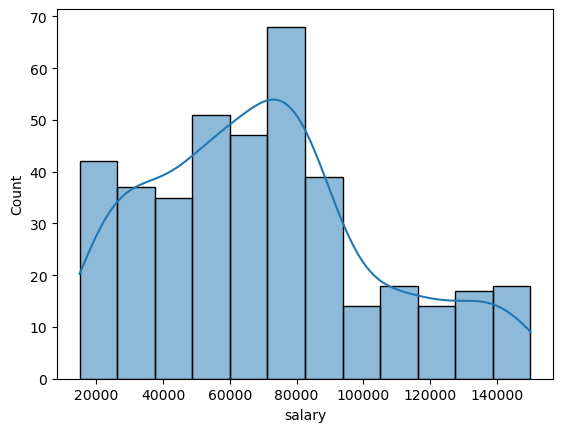

In [74]:
# Salary distribution
sns.histplot(df['salary'], kde=True)
plt.show()

In [82]:
# Remove the 'id' column from the dataframe as it's not needed for analysis
df = df.drop('id', axis=1)

In [84]:
# Initialize a LabelEncoder to convert categorical text values to numerical values
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])

In [85]:
# Separate features (X) from target variable (y)
X = df.drop('buy', axis=1)  # Features: all columns except 'buy'
y = df['buy']  # Target variable: 'buy' column

In [78]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [44]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [45]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [46]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [47]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [48]:
svm = SVC(probability=True)
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

In [49]:
def evaluate_model(name, y_test, y_pred, model):
    print("======", name, "======")
    
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    y_prob = model.predict_proba(X_test)[:,1]
    auc = roc_auc_score(y_test, y_prob)
    print("\nAUC-ROC:", auc)
    
    print("\n---------------------------\n")

In [50]:
evaluate_model("Logistic Regression", y_test, y_pred_lr, lr)
evaluate_model("Decision Tree", y_test, y_pred_dt, dt)
evaluate_model("Random Forest", y_test, y_pred_rf, rf)
evaluate_model("SVM", y_test, y_pred_svm, svm)

====== Logistic Regression ======

Confusion Matrix:
[[50  2]
 [ 7 21]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92        52
           1       0.91      0.75      0.82        28

    accuracy                           0.89        80
   macro avg       0.90      0.86      0.87        80
weighted avg       0.89      0.89      0.88        80


AUC-ROC: 0.9684065934065934

---------------------------

====== Decision Tree ======

Confusion Matrix:
[[46  6]
 [ 8 20]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.88      0.87        52
           1       0.77      0.71      0.74        28

    accuracy                           0.82        80
   macro avg       0.81      0.80      0.80        80
weighted avg       0.82      0.82      0.82        80


AUC-ROC: 0.7994505494505495

---------------------------

====== Random Forest ======

Confusion Mat

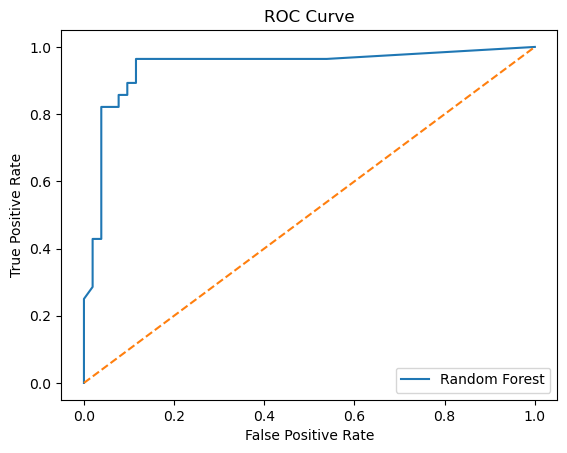

In [51]:
y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label="Random Forest")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [52]:
# Store models and predictions
models = {
    "Logistic Regression": (lr, y_pred_lr),
    "Decision Tree": (dt, y_pred_dt),
    "Random Forest": (rf, y_pred_rf),
    "SVM": (svm, y_pred_svm)
}

results = []

from sklearn.metrics import recall_score, f1_score, accuracy_score

for name, (model, y_pred) in models.items():
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    
    results.append([name, acc, recall, f1, auc])

# Convert to DataFrame
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Recall", "F1 Score", "AUC"])

print(results_df.sort_values(by="Recall", ascending=False))

                 Model  Accuracy    Recall  F1 Score       AUC
3                  SVM    0.9250  0.928571  0.896552  0.969780
2        Random Forest    0.8875  0.857143  0.842105  0.939904
0  Logistic Regression    0.8875  0.750000  0.823529  0.968407
1        Decision Tree    0.8250  0.714286  0.740741  0.799451


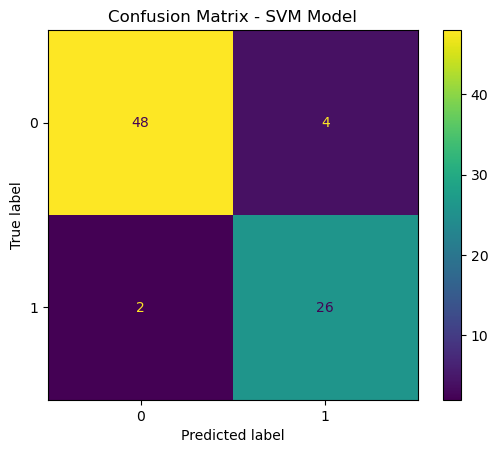

In [87]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_svm)

# Display it
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - SVM Model")
plt.show()